# Stage_1(Data Understanding)

In [1]:
print('Hello_World')

Hello_World


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('heart_disease_uci.csv')

In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nDataset Info")
df.info()

print("\nStatistical Summary")
df.describe().T

Shape: (920, 16)

Data Types
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpea

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


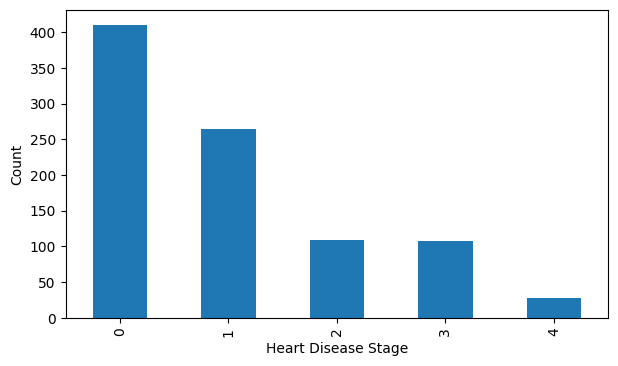

In [8]:
import matplotlib.pyplot as plt

df['num'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(7,4)
)

plt.xlabel("Heart Disease Stage")
plt.ylabel("Count")
plt.show()

In [9]:
print(df['num'].value_counts(normalize=True).sort_index()*100)

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64


In [10]:
df.drop(columns='id', inplace=True)

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

print(numerical_cols)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')


In [12]:
categorical_cols = df.select_dtypes(exclude=np.number).columns

print(categorical_cols)

Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*40)

age
[63 67 37 41 56 62 57 53 44 52 48 54 49 64 58 60 50 66 43 40 69 59 42 55
 61 65 71 51 46 45 39 68 47 34 35 29 70 77 38 74 76 28 30 31 32 33 36 72
 73 75]
----------------------------------------
sex
['Male' 'Female']
----------------------------------------
dataset
['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
----------------------------------------
cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
----------------------------------------
trestbps
[145. 160. 120. 130. 140. 172. 150. 110. 132. 117. 135. 112. 105. 124.
 125. 142. 128. 170. 155. 104. 180. 138. 108. 134. 122. 115. 118. 100.
 200.  94. 165. 102. 152. 101. 126. 174. 148. 178. 158. 192. 129. 144.
 123. 136. 146. 106. 156. 154. 114. 164.  98. 190.  nan 113.  92.  95.
  80. 185. 116.   0.  96. 127.]
----------------------------------------
chol
[233. 286. 229. 250. 204. 236. 268. 354. 254. 203. 192. 294. 256. 263.
 199. 168. 239. 275. 266. 211. 283. 284. 224. 206. 219. 340. 226. 247.
 167. 230. 3

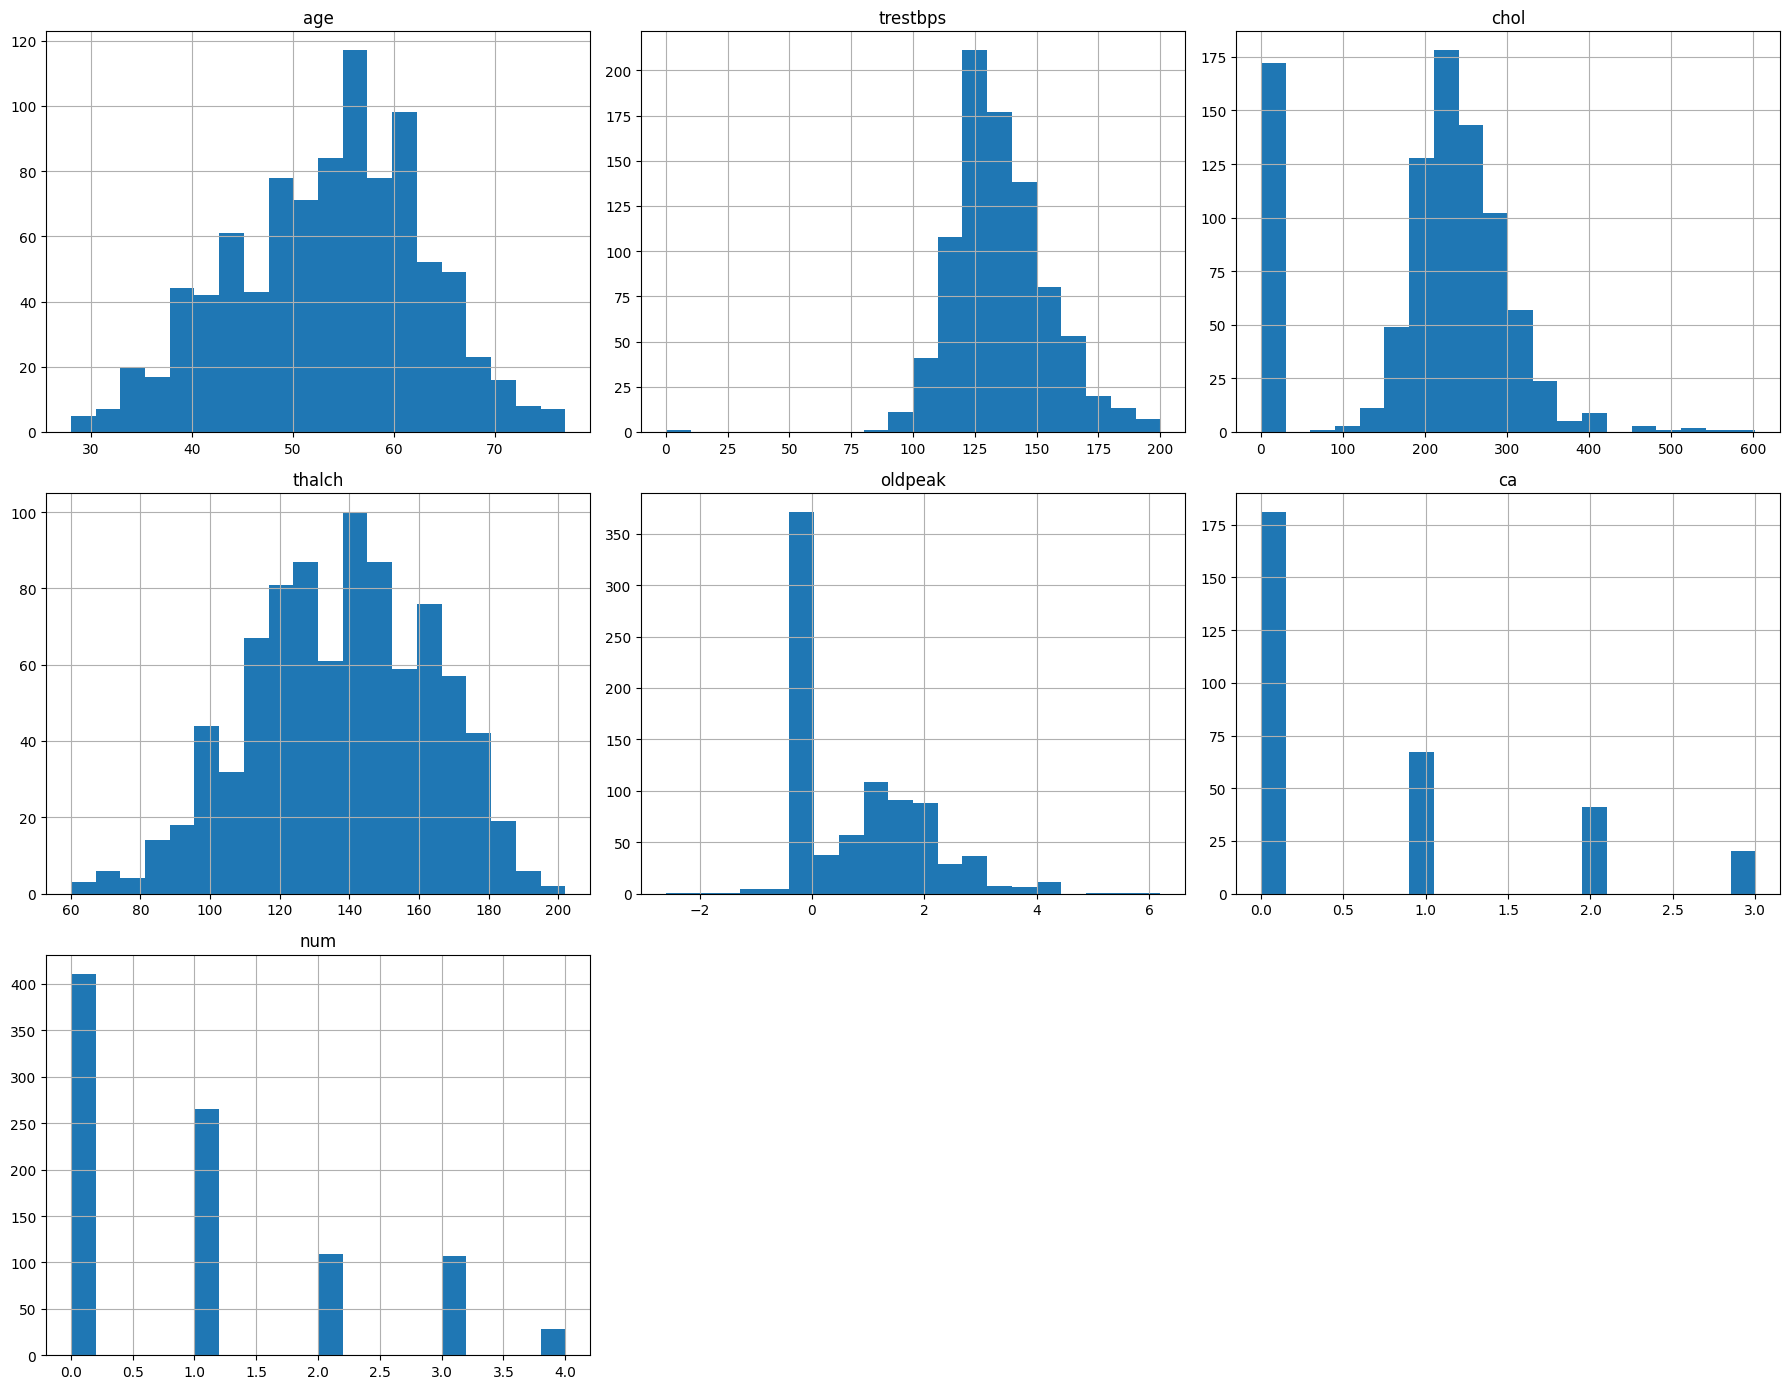

In [14]:
df.hist(
    figsize=(18,14),
    bins=20
)

plt.tight_layout()
plt.show()

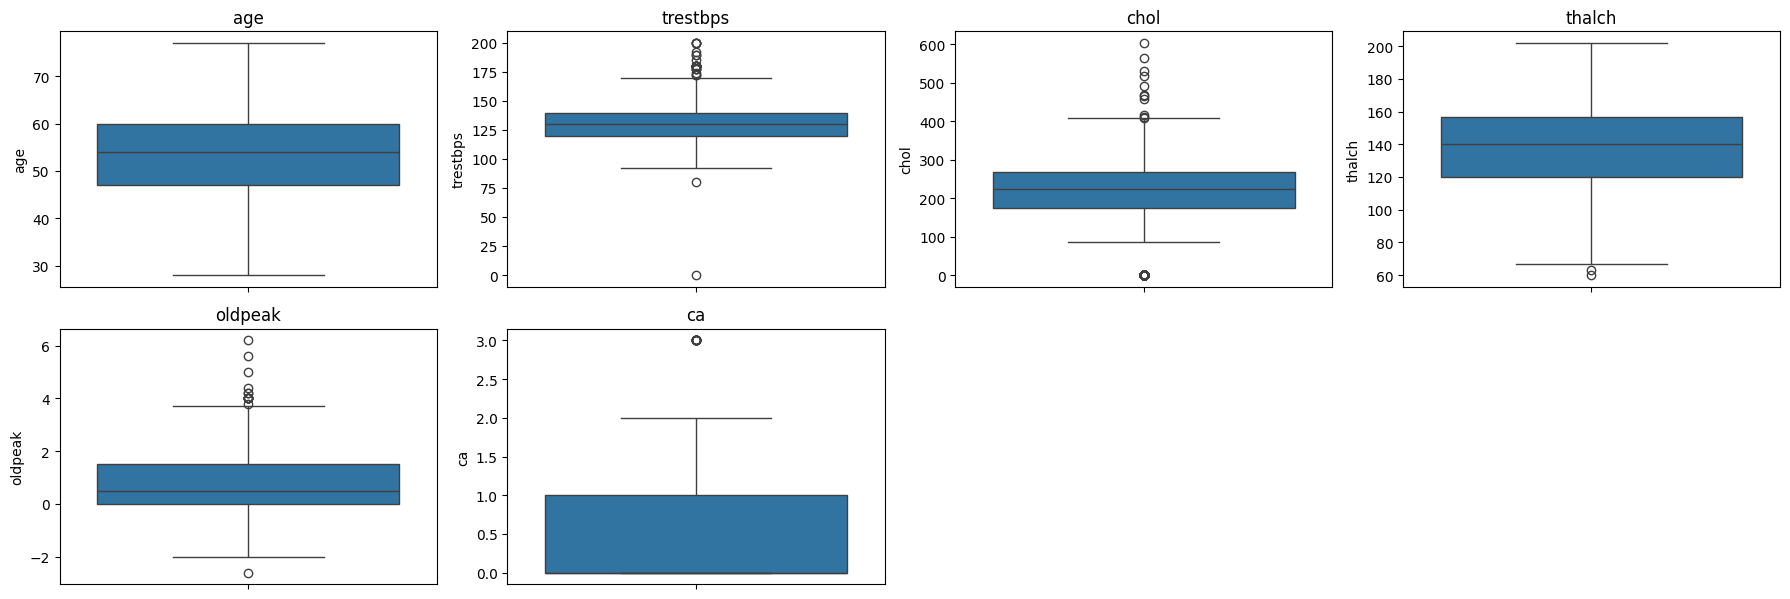

In [15]:
numeric_cols = df.select_dtypes(include='number').columns.drop('num')

plt.figure(figsize=(18,12))

for i,col in enumerate(numeric_cols):

    plt.subplot(4,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

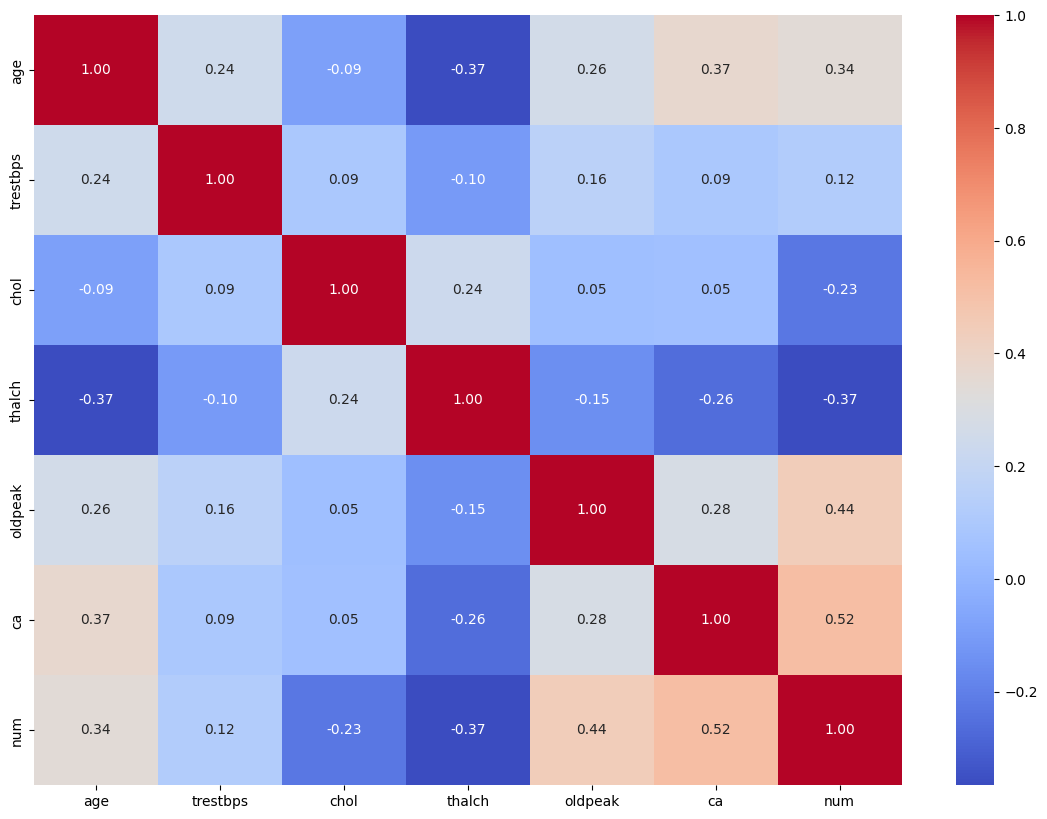

In [16]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [17]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [18]:
(df.isnull().mean()*100).sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
thalch       5.978261
exang        5.978261
chol         3.260870
restecg      0.217391
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
num          0.000000
dtype: float64

In [19]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 2


In [20]:
df["num"].value_counts().sort_index()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_19204\1798074014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


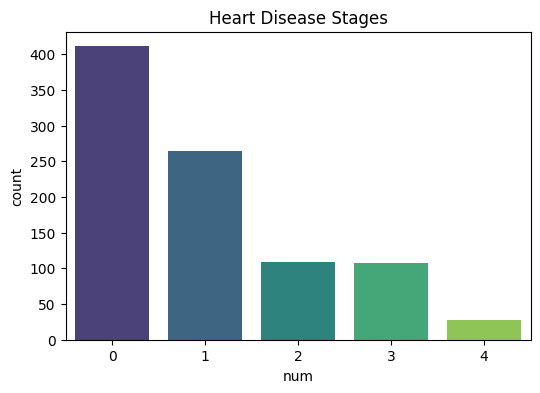

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="num",
    palette="viridis",
)

plt.title("Heart Disease Stages")
plt.show()

In [22]:
print(df.shape)

(920, 15)


# Stage_2(Data-Cleaning)

In [23]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Count,Percentage
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
thalch,55,5.978261
exang,55,5.978261
chol,30,3.260870
restecg,2,0.217391


In [24]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 2


In [25]:
df["num"].value_counts().sort_index()

num
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64

In [26]:
df.drop(columns='ca', inplace=True)

# Stage_3(EDA)

C:\Users\HP\AppData\Local\Temp\ipykernel_19204\1066722931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


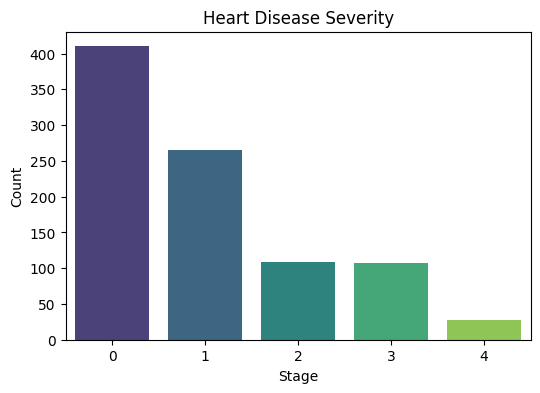

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="num",
    palette="viridis"
)

plt.title("Heart Disease Severity")
plt.xlabel("Stage")
plt.ylabel("Count")

plt.show()

In [28]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         29
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       307
thal        484
num           0
dtype: int64

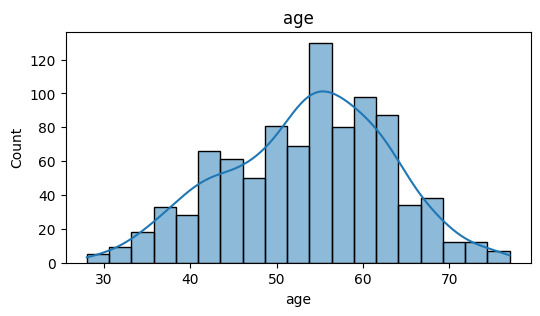

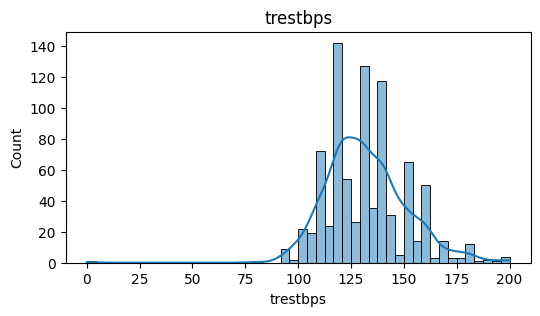

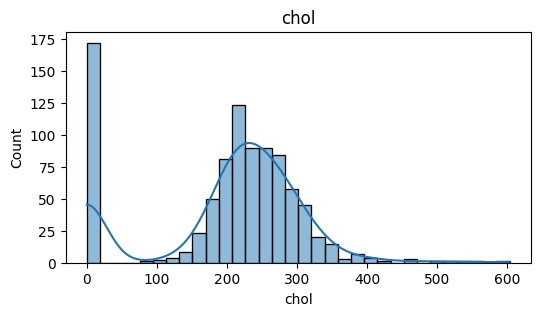

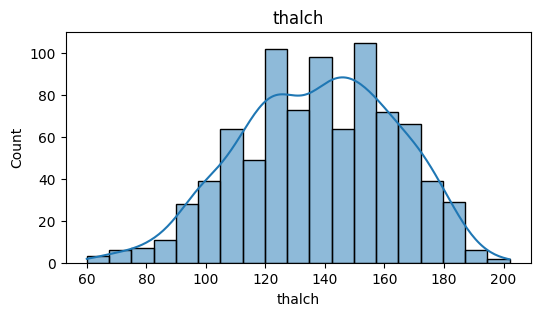

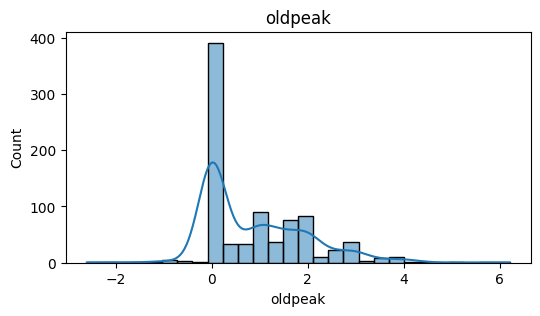

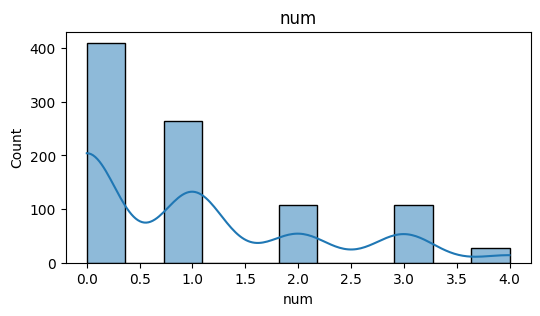

In [29]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

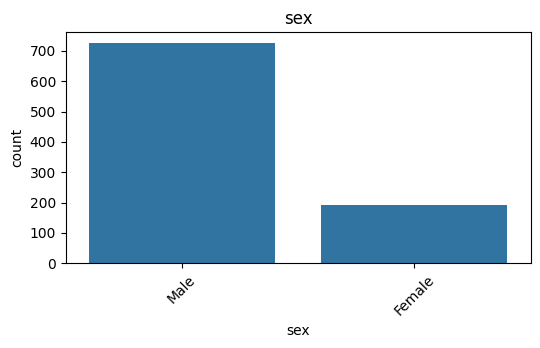

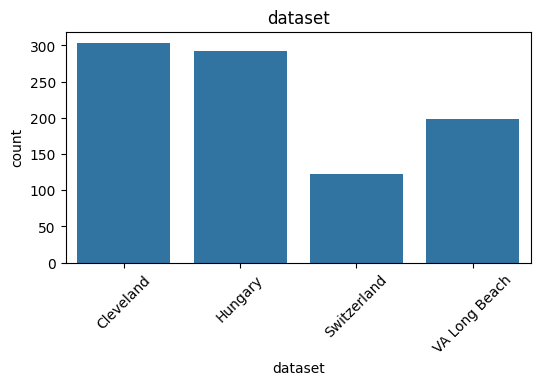

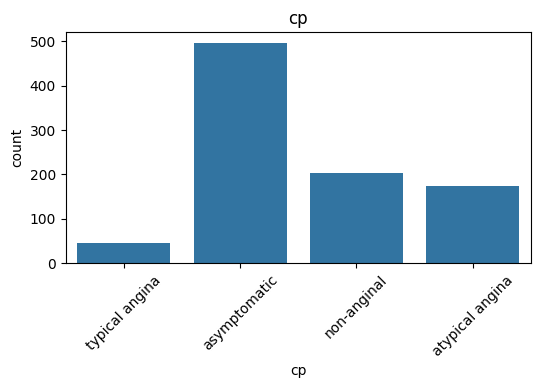

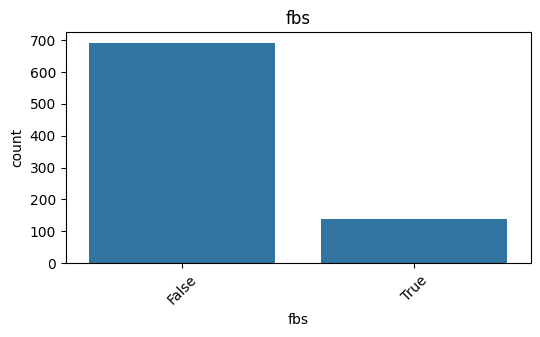

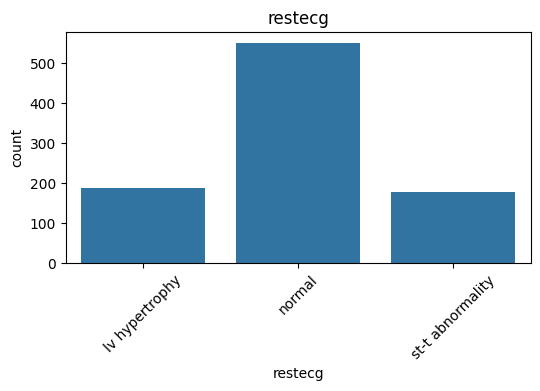

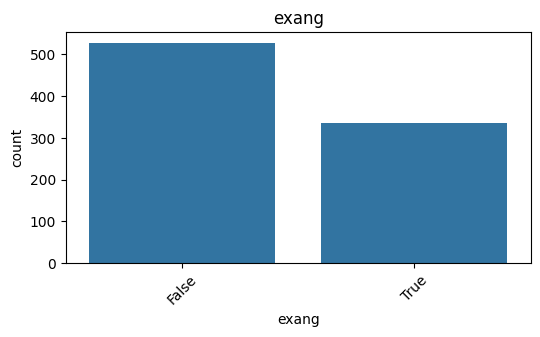

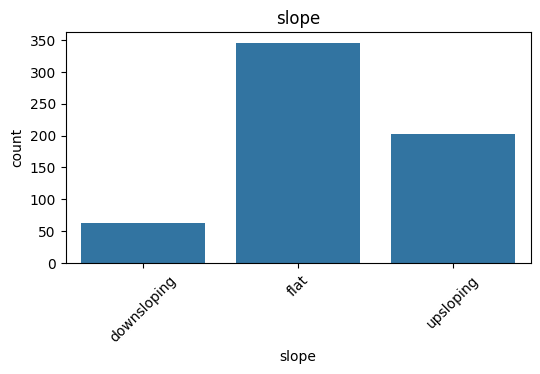

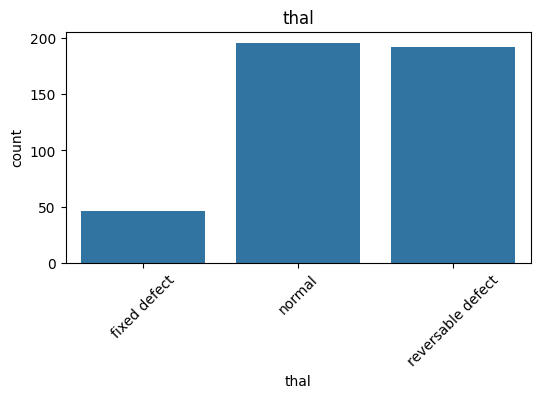

In [30]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

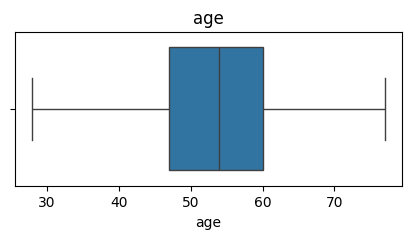

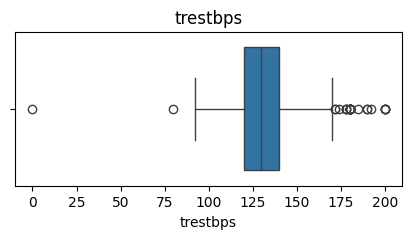

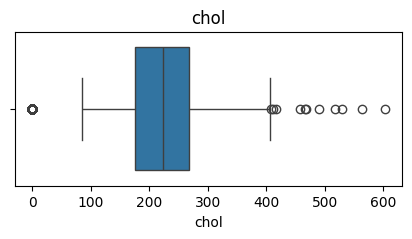

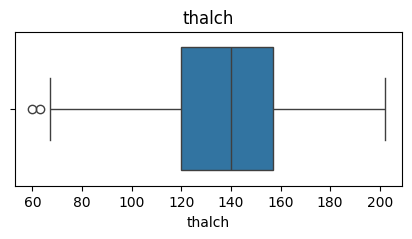

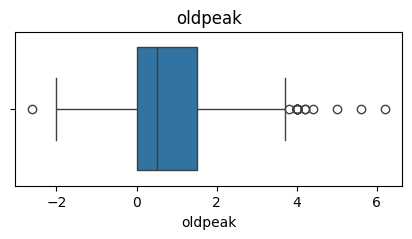

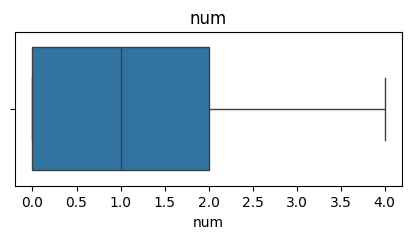

In [31]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

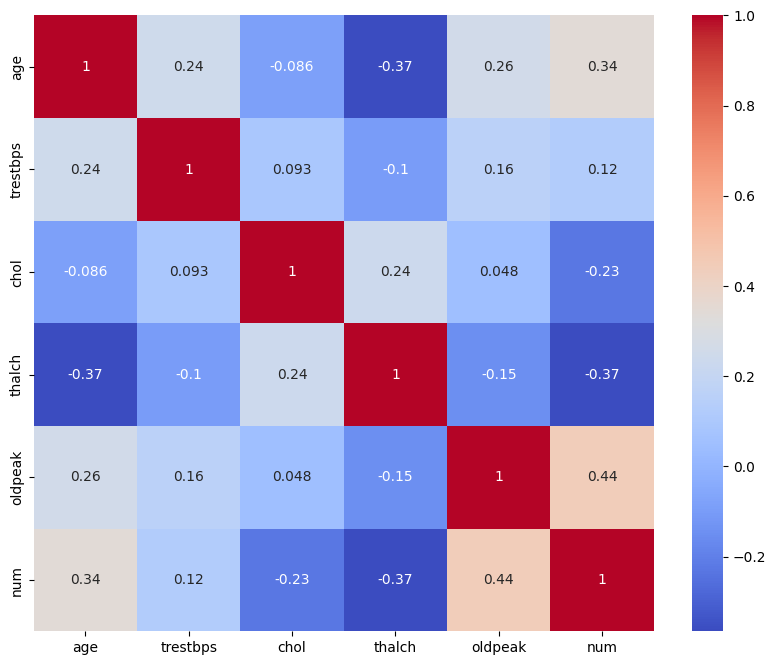

In [32]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Stage_4(Feature-Selection)

In [33]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('num')
cat_cols = df.select_dtypes(include='object').columns

print(num_cols)
print(cat_cols)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak'], dtype='object')
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [34]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

df[['trestbps','chol','thalch','oldpeak']] = num_imputer.fit_transform(
    df[['trestbps','chol','thalch','oldpeak']]
)

In [35]:
cat_imputer = SimpleImputer(strategy="most_frequent")

df[['fbs','restecg','exang','slope','thal']] = cat_imputer.fit_transform(
    df[['fbs','restecg','exang','slope','thal']]
)

In [36]:
df.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [37]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [38]:
df.head()

,age,trestbps,chol,thalch,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0,True,False,False,False,...,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,2,True,False,False,False,...,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,...,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0,True,False,False,False,...,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


In [39]:
X = df.drop('num', axis=1)
y = df['num']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(734, 20)
(184, 20)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [42]:
X_train.head()

,age,trestbps,chol,thalch,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
637,-0.032164,-0.621711,-1.766312,-1.705680,-0.807493,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False
352,-1.308301,-0.621711,0.890155,1.268589,-0.807493,True,True,False,False,True,False,False,False,True,False,False,True,False,True,False
136,1.775697,0.711513,-0.199447,-0.515972,1.640901,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True
40,1.243973,0.978158,0.259807,-0.952198,0.134197,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
530,-1.520991,-1.155001,0.755081,0.475451,-0.807493,True,True,False,False,False,False,False,False,True,False,False,True,False,False,False


# Stage_5(Baseline_Models)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    mean_absolute_error,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print(f"Accuracy              : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Weighted F1 Score     : {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Quadratic Kappa       : {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.4f}")
    print(f"Mean Absolute Error   : {mean_absolute_error(y_test, y_pred):.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,5))

    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(model.__class__.__name__)

    plt.show()

In [44]:
results = []

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error
)

def compare_model(model):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({

        "Model": model.__class__.__name__,

        "Accuracy": accuracy_score(y_test, pred),

        "Weighted F1": f1_score(
            y_test,
            pred,
            average="weighted"
        ),

        "QWK": cohen_kappa_score(
            y_test,
            pred,
            weights="quadratic"
        ),

        "MAE": mean_absolute_error(
            y_test,
            pred
        )
    })

## Logistic Regression

LogisticRegression
Accuracy              : 0.5978
Weighted F1 Score     : 0.5647
Quadratic Kappa       : 0.6348
Mean Absolute Error   : 0.5380

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.87      0.84        82
           1       0.47      0.62      0.54        53
           2       0.17      0.05      0.07        22
           3       0.24      0.24      0.24        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.34      0.35      0.34       184
weighted avg       0.55      0.60      0.56       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


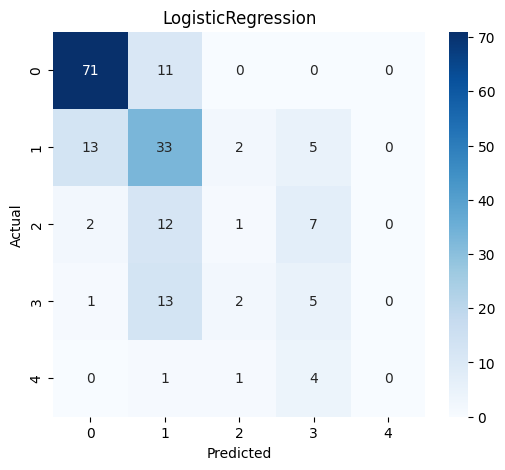

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

evaluate_model(
    lr,
    X_train,
    X_test,
    y_train,
    y_test
)

In [46]:
compare_model(lr)

## Decision Tree

DecisionTreeClassifier
Accuracy              : 0.5326
Weighted F1 Score     : 0.5406
Quadratic Kappa       : 0.5308
Mean Absolute Error   : 0.6793

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.70      0.73        82
           1       0.52      0.55      0.53        53
           2       0.23      0.27      0.25        22
           3       0.17      0.19      0.18        21
           4       0.50      0.33      0.40         6

    accuracy                           0.53       184
   macro avg       0.44      0.41      0.42       184
weighted avg       0.55      0.53      0.54       184



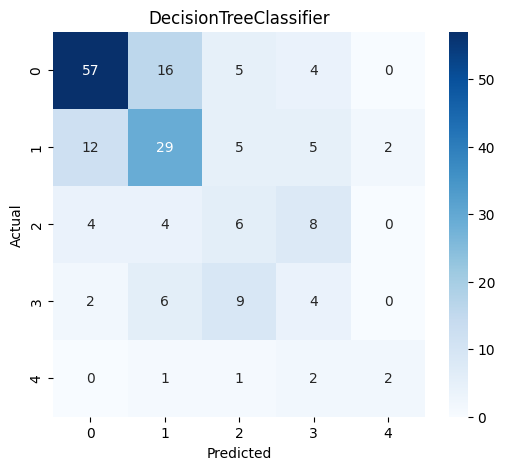

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

In [48]:
compare_model(dt)

## Random Forest 

RandomForestClassifier
Accuracy              : 0.5707
Weighted F1 Score     : 0.5575
Quadratic Kappa       : 0.5376
Mean Absolute Error   : 0.6359

Classification Report

              precision    recall  f1-score   support

           0       0.74      0.83      0.78        82
           1       0.48      0.47      0.48        53
           2       0.30      0.27      0.29        22
           3       0.26      0.24      0.25        21
           4       1.00      0.17      0.29         6

    accuracy                           0.57       184
   macro avg       0.56      0.40      0.42       184
weighted avg       0.57      0.57      0.56       184



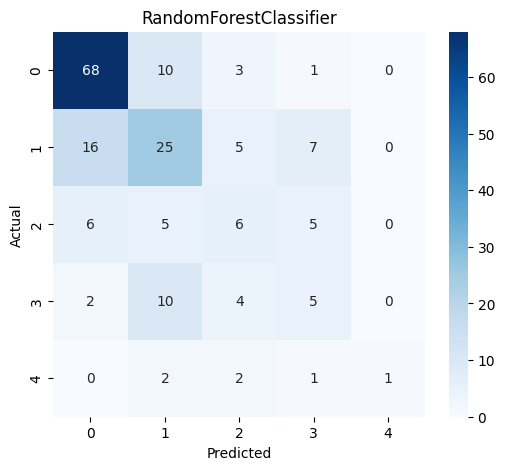

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

In [50]:
compare_model(rf)

## Gradient Boosting

GradientBoostingClassifier
Accuracy              : 0.6196
Weighted F1 Score     : 0.6007
Quadratic Kappa       : 0.6025
Mean Absolute Error   : 0.5272

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.52      0.64      0.58        53
           2       0.36      0.36      0.36        22
           3       0.25      0.14      0.18        21
           4       0.00      0.00      0.00         6

    accuracy                           0.62       184
   macro avg       0.39      0.40      0.39       184
weighted avg       0.59      0.62      0.60       184



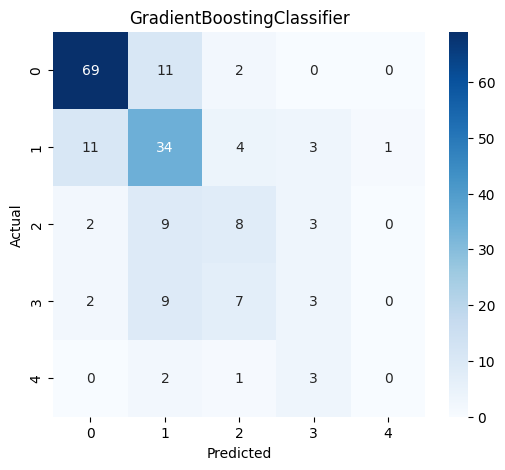

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

In [52]:
compare_model(gb)

## ADA_Boost

AdaBoostClassifier
Accuracy              : 0.6413
Weighted F1 Score     : 0.5957
Quadratic Kappa       : 0.5693
Mean Absolute Error   : 0.5326

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.90      0.82        82
           1       0.54      0.68      0.60        53
           2       0.50      0.09      0.15        22
           3       0.40      0.29      0.33        21
           4       0.00      0.00      0.00         6

    accuracy                           0.64       184
   macro avg       0.44      0.39      0.38       184
weighted avg       0.60      0.64      0.60       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


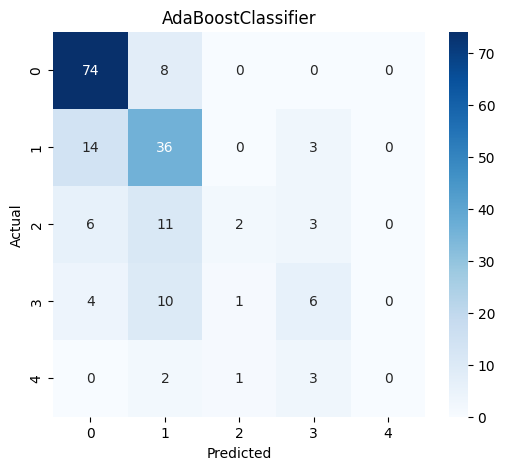

In [53]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

evaluate_model(
    ada,
    X_train,
    X_test,
    y_train,
    y_test
)

In [54]:
compare_model(ada)

## XG_Boost

XGBClassifier
Accuracy              : 0.6250
Weighted F1 Score     : 0.6126
Quadratic Kappa       : 0.6697
Mean Absolute Error   : 0.5000

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.85      0.83        82
           1       0.55      0.57      0.56        53
           2       0.36      0.36      0.36        22
           3       0.37      0.33      0.35        21
           4       0.00      0.00      0.00         6

    accuracy                           0.62       184
   macro avg       0.42      0.42      0.42       184
weighted avg       0.60      0.62      0.61       184



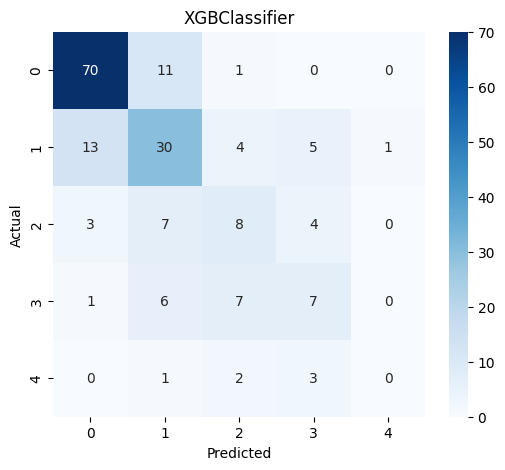

In [55]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

evaluate_model(
    xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

In [56]:
compare_model(xgb)

## LGBM

In [57]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier

LGBMClassifier
Accuracy              : 0.6250
Weighted F1 Score     : 0.6134
Quadratic Kappa       : 0.6527
Mean Absolute Error   : 0.5054

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.56      0.62      0.59        53
           2       0.32      0.32      0.32        22
           3       0.33      0.29      0.31        21
           4       0.00      0.00      0.00         6

    accuracy                           0.62       184
   macro avg       0.41      0.41      0.41       184
weighted avg       0.60      0.62      0.61       184



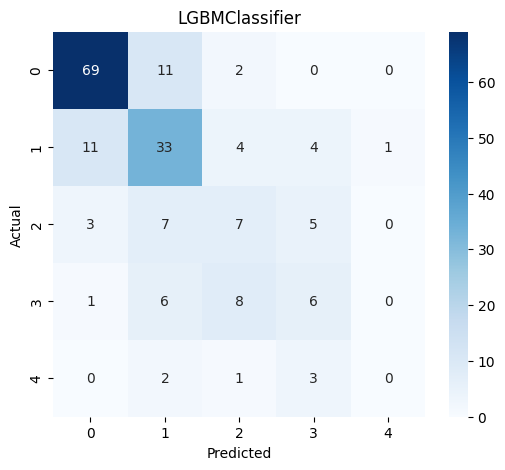

In [58]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    num_leaves=15,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)
evaluate_model(
    lgbm,
    X_train,
    X_test,
    y_train,
    y_test
)

In [59]:
compare_model(lgbm)

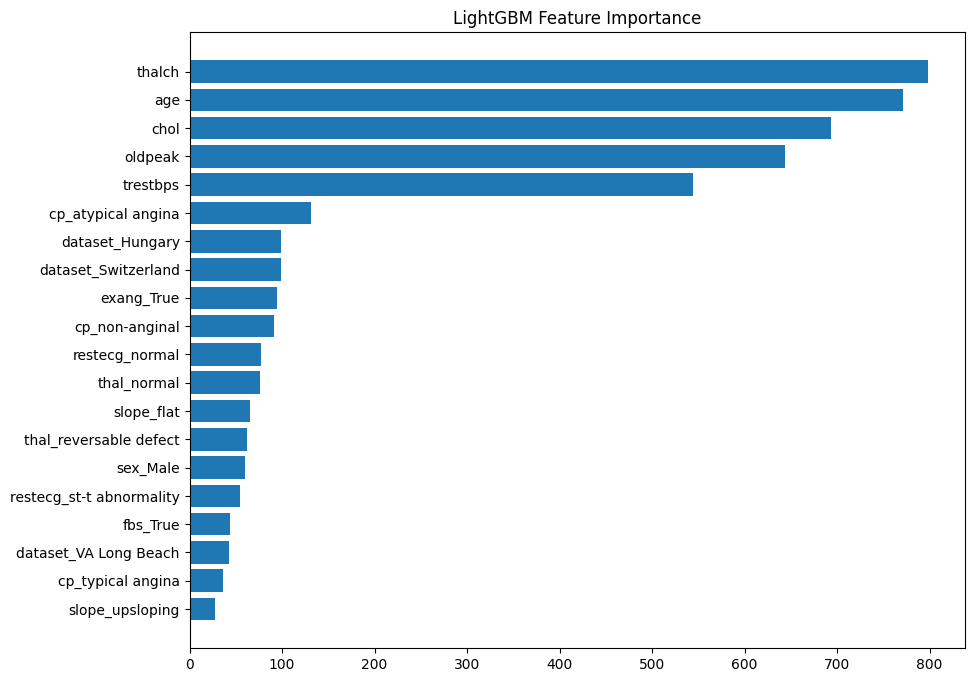

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("LightGBM Feature Importance")

plt.show()

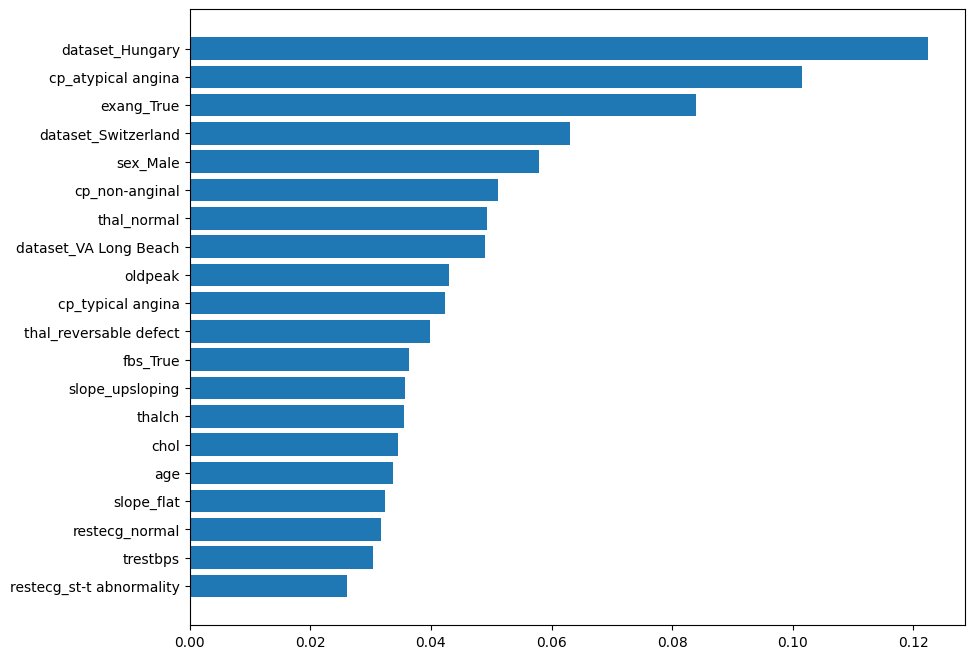

In [61]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.show()

## Cat_Boost

CatBoostClassifier
Accuracy              : 0.5924
Weighted F1 Score     : 0.5762
Quadratic Kappa       : 0.6259
Mean Absolute Error   : 0.5489

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        82
           1       0.48      0.58      0.53        53
           2       0.27      0.18      0.22        22
           3       0.29      0.29      0.29        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.37      0.38      0.37       184
weighted avg       0.56      0.59      0.58       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


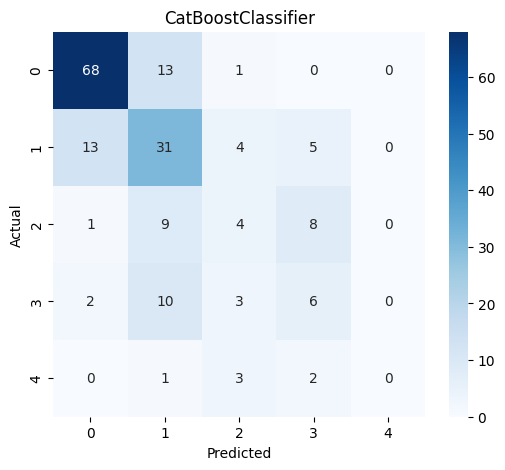

In [62]:
!pip install catboost -q
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

evaluate_model(
    cat,
    X_train,
    X_test,
    y_train,
    y_test
)

compare_model(cat)

## KNN

KNeighborsClassifier
Accuracy              : 0.5707
Weighted F1 Score     : 0.5472
Quadratic Kappa       : 0.5962
Mean Absolute Error   : 0.5761

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.83      0.79        82
           1       0.49      0.57      0.53        53
           2       0.25      0.18      0.21        22
           3       0.18      0.14      0.16        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.33      0.34      0.34       184
weighted avg       0.53      0.57      0.55       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


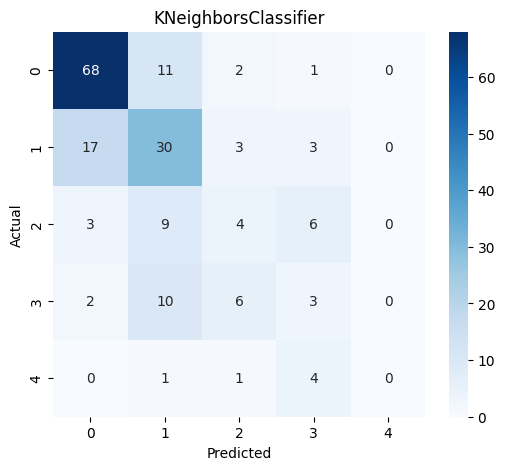

In [63]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p=2
)

evaluate_model(
    knn,
    X_train,
    X_test,
    y_train,
    y_test
)

In [64]:
compare_model(knn)

## SVC

SVC
Accuracy              : 0.6087
Weighted F1 Score     : 0.5663
Quadratic Kappa       : 0.5786
Mean Absolute Error   : 0.5489

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.89      0.82        82
           1       0.51      0.64      0.57        53
           2       0.25      0.09      0.13        22
           3       0.21      0.14      0.17        21
           4       0.00      0.00      0.00         6

    accuracy                           0.61       184
   macro avg       0.35      0.35      0.34       184
weighted avg       0.54      0.61      0.57       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


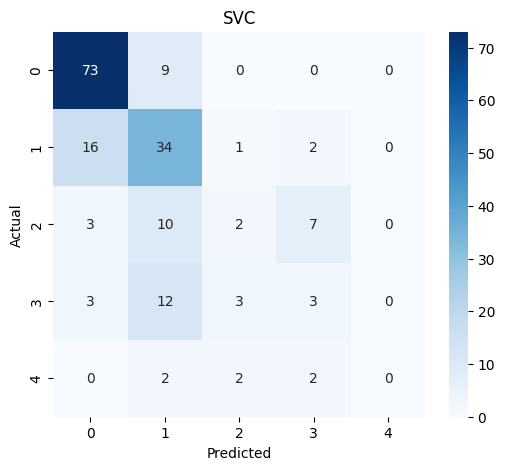

In [65]:
from sklearn.svm import SVC
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

evaluate_model(
    svm,
    X_train,
    X_test,
    y_train,
    y_test
)

In [66]:
compare_model(svm)

## Compairing_Models

In [67]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="QWK",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Weighted F1,QWK,MAE
0,XGBClassifier,0.625000,0.612627,0.669725,0.500000
1,LGBMClassifier,0.625000,0.613382,0.652681,0.505435
2,LogisticRegression,0.597826,0.564728,0.634845,0.538043
3,CatBoostClassifier,0.592391,0.576212,0.625882,0.548913
4,GradientBoostingClassifier,0.619565,0.600702,0.602469,0.527174
5,KNeighborsClassifier,0.570652,0.547170,0.596154,0.576087
6,SVC,0.608696,0.566332,0.578554,0.548913
7,AdaBoostClassifier,0.641304,0.595689,0.569307,0.532609
8,RandomForestClassifier,0.570652,0.557500,0.537585,0.635870
9,DecisionTreeClassifier,0.532609,0.540551,0.530786,0.679348


# Stage_6(Hyperparameter Tunning)

## LGBM

In [68]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    random_state=42,
    verbose=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_samples": [10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a funct

In [69]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Best CV Score:
0.5885844748858448


LGBMClassifier
Accuracy              : 0.6087
Weighted F1 Score     : 0.5751
Quadratic Kappa       : 0.5472
Mean Absolute Error   : 0.5707

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.89      0.82        82
           1       0.52      0.60      0.56        53
           2       0.25      0.14      0.18        22
           3       0.25      0.19      0.22        21
           4       0.00      0.00      0.00         6

    accuracy                           0.61       184
   macro avg       0.36      0.36      0.36       184
weighted avg       0.55      0.61      0.58       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


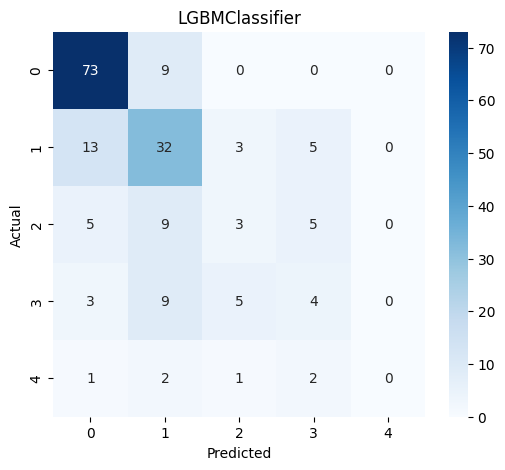

In [70]:
best_lgbm = random_search.best_estimator_

evaluate_model(
    best_lgbm,
    X_train,
    X_test,
    y_train,
    y_test
)

In [71]:
compare_model(best_lgbm)

## XGB

In [72]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    random_state=42,
    eval_metric='mlogloss'
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=5, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

In [73]:
print("Best Parameters:")
print(random_search_xgb.best_params_)

print("\nBest Cross Validation Score:")
print(random_search_xgb.best_score_)

Best Parameters:
{'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}

Best Cross Validation Score:
0.5624518756530215


XGBClassifier
Accuracy              : 0.6141
Weighted F1 Score     : 0.5900
Quadratic Kappa       : 0.5942
Mean Absolute Error   : 0.5435

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        82
           1       0.56      0.66      0.60        53
           2       0.25      0.18      0.21        22
           3       0.24      0.19      0.21        21
           4       0.00      0.00      0.00         6

    accuracy                           0.61       184
   macro avg       0.37      0.38      0.37       184
weighted avg       0.57      0.61      0.59       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


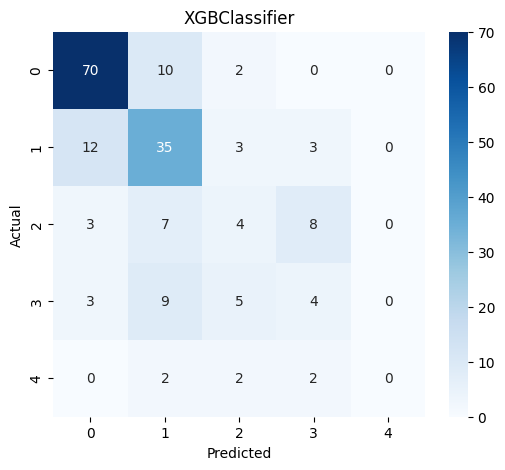

In [74]:
best_xgb = random_search_xgb.best_estimator_

evaluate_model(
    best_xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

In [75]:
compare_model(best_xgb)

## Cat_Boost

In [76]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

In [77]:
cat = CatBoostClassifier(
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

In [78]:
param_dist = {
    "iterations": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 5, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": [0, 0.5, 1, 3, 5],
    "random_strength": [1, 2, 5, 10]
}

In [79]:
random_search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search_cat.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bagging_temperature': [0, 0.5, ...], 'border_count': [32, 64, ...], 'depth': [4, 5, ...], 'iterations': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichr

In [80]:
print("Best Parameters:")
print(random_search_cat.best_params_)

print("\nBest CV Score:")
print(random_search_cat.best_score_)

Best Parameters:
{'random_strength': 10, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 4, 'border_count': 254, 'bagging_temperature': 0}

Best CV Score:
0.5568707581254444


CatBoostClassifier
Accuracy              : 0.6413
Weighted F1 Score     : 0.6212
Quadratic Kappa       : 0.6589
Mean Absolute Error   : 0.4946

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.89      0.84        82
           1       0.56      0.58      0.57        53
           2       0.41      0.32      0.36        22
           3       0.35      0.33      0.34        21
           4       0.00      0.00      0.00         6

    accuracy                           0.64       184
   macro avg       0.42      0.43      0.42       184
weighted avg       0.61      0.64      0.62       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


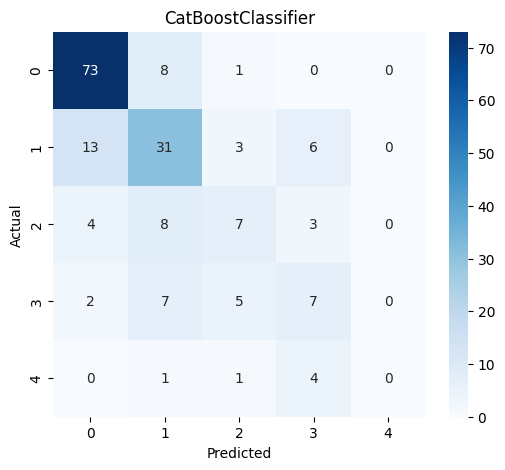

In [81]:
best_cat = random_search_cat.best_estimator_

evaluate_model(
    best_cat,
    X_train,
    X_test,
    y_train,
    y_test
)

In [82]:
compare_model(best_cat)

# Stage_7(More_Ensembling_Techniques)

## Voting_Classifier

In [83]:
from sklearn.ensemble import VotingClassifier

In [84]:
voting = VotingClassifier(
    estimators=[
        ('lgbm', best_lgbm),
        ('xgb', best_xgb),
        ('cat', best_cat)
    ],
    voting='soft'
)

VotingClassifier
Accuracy              : 0.6087
Weighted F1 Score     : 0.5857
Quadratic Kappa       : 0.5961
Mean Absolute Error   : 0.5435

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.84      0.82        82
           1       0.52      0.64      0.58        53
           2       0.35      0.27      0.31        22
           3       0.20      0.14      0.17        21
           4       0.00      0.00      0.00         6

    accuracy                           0.61       184
   macro avg       0.37      0.38      0.37       184
weighted avg       0.57      0.61      0.59       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


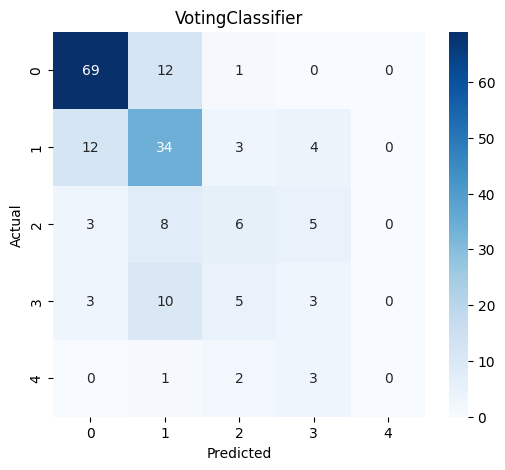

In [85]:
evaluate_model(
    voting,
    X_train,
    X_test,
    y_train,
    y_test
)

In [86]:
compare_model(voting)

## Stacking_Classifier

In [87]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [88]:
stack = StackingClassifier(
    estimators=[
        ('lgbm', best_lgbm),
        ('xgb', best_xgb),
        ('cat', best_cat)
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    cv=5,
    n_jobs=-1
)

StackingClassifier
Accuracy              : 0.5924
Weighted F1 Score     : 0.5686
Quadratic Kappa       : 0.5966
Mean Absolute Error   : 0.5598

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.83      0.82        82
           1       0.49      0.66      0.56        53
           2       0.25      0.14      0.18        22
           3       0.17      0.14      0.15        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.35      0.35      0.34       184
weighted avg       0.56      0.59      0.57       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


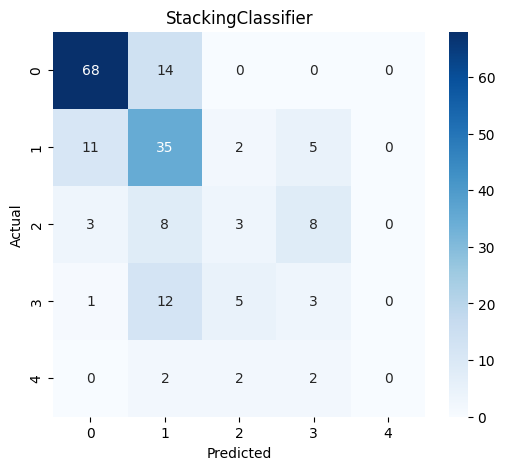

In [89]:
evaluate_model(
    stack,
    X_train,
    X_test,
    y_train,
    y_test
)

In [90]:
compare_model(stack)

## Compairing results

In [91]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="QWK",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Weighted F1,QWK,MAE
0,XGBClassifier,0.625000,0.612627,0.669725,0.500000
1,CatBoostClassifier,0.641304,0.621189,0.658933,0.494565
2,LGBMClassifier,0.625000,0.613382,0.652681,0.505435
3,LogisticRegression,0.597826,0.564728,0.634845,0.538043
4,CatBoostClassifier,0.592391,0.576212,0.625882,0.548913
5,GradientBoostingClassifier,0.619565,0.600702,0.602469,0.527174
6,StackingClassifier,0.592391,0.568589,0.596577,0.559783
7,KNeighborsClassifier,0.570652,0.547170,0.596154,0.576087
8,VotingClassifier,0.608696,0.585708,0.596059,0.543478
9,XGBClassifier,0.614130,0.590026,0.594203,0.543478


# Stage_8(Ordinal_Classification)

In [92]:
!pip install mord

In [93]:
from mord import LogisticIT

In [94]:
ordinal_model = LogisticIT()

ordinal_model.fit(X_train, y_train)

,alpha,1.0
,verbose,0
,max_iter,1000
Name,Type,Value
classes_,"ndarray[int64](5,)","[0,1,2,3,4]"
coef_,"ndarray[float64](20,)","[ 0.2 ,-0.02, 0.05,...,-0.12,-0.5 ,-0.04]"
n_class_,int64,np.int64(5)
theta_,"ndarray[float64](4,)","[0.2 ,1.59,1.59,2.99]"


In [95]:
y_pred = ordinal_model.predict(X_test)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    mean_absolute_error,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Weighted F1 :", f1_score(
    y_test,
    y_pred,
    average="weighted"
))

print("QWK :", cohen_kappa_score(
    y_test,
    y_pred,
    weights="quadratic"
))

print("MAE :", mean_absolute_error(
    y_test,
    y_pred
))

print(classification_report(
    y_test,
    y_pred
))

Accuracy : 0.5597826086956522
Weighted F1 : 0.5253635253635254
QWK : 0.6077586206896552
MAE : 0.6086956521739131
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        82
           1       0.39      0.47      0.43        53
           2       0.00      0.00      0.00        22
           3       0.29      0.48      0.36        21
           4       0.00      0.00      0.00         6

    accuracy                           0.56       184
   macro avg       0.30      0.36      0.32       184
weighted avg       0.50      0.56      0.53       184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [97]:
import numpy as np

distance = np.abs(y_test - y_pred)

print(distance)

print("Average Distance Error:", np.mean(distance))

529    1
711    0
919    1
146    3
887    1
      ..
59     0
572    1
687    1
662    1
836    1
Name: num, Length: 184, dtype: int64
Average Distance Error: 0.6086956521739131


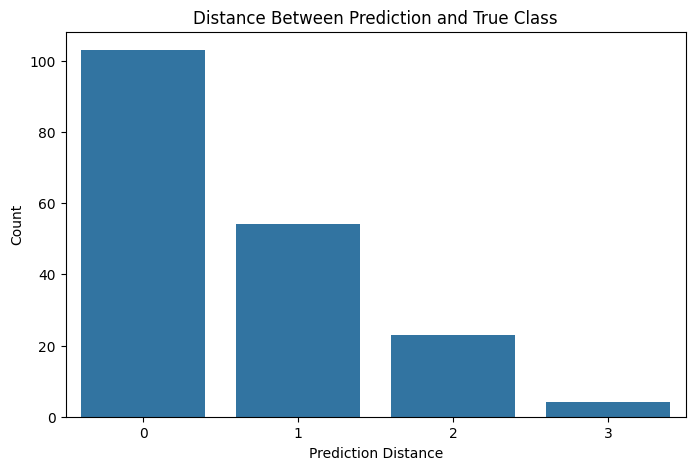

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x=distance)

plt.xlabel("Prediction Distance")

plt.ylabel("Count")

plt.title("Distance Between Prediction and True Class")

plt.show()

# Stage_9(Error_analysis)

In [99]:
!pip install shap

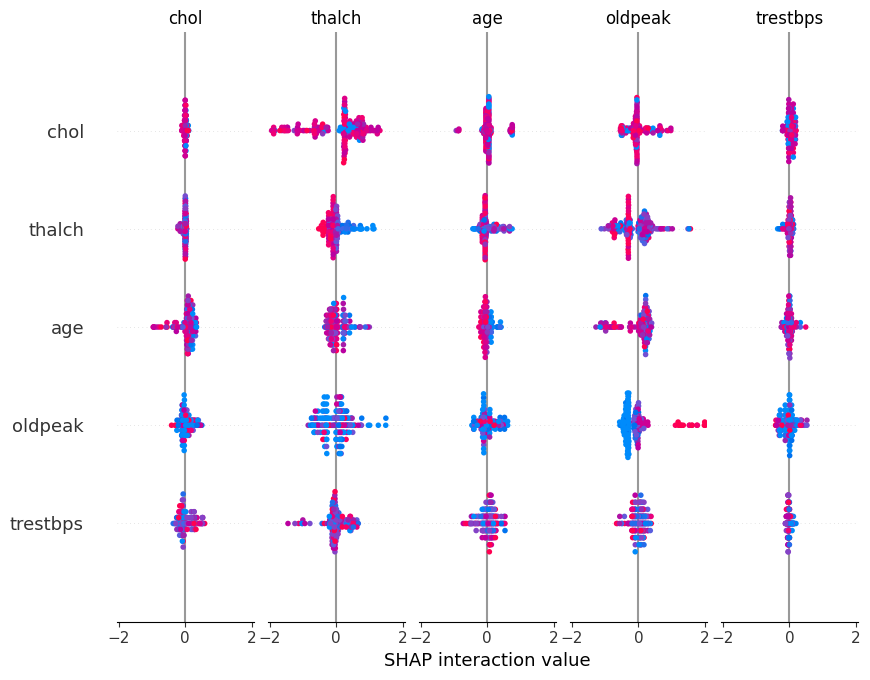

In [100]:
import shap

explainer = shap.TreeExplainer(best_lgbm)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

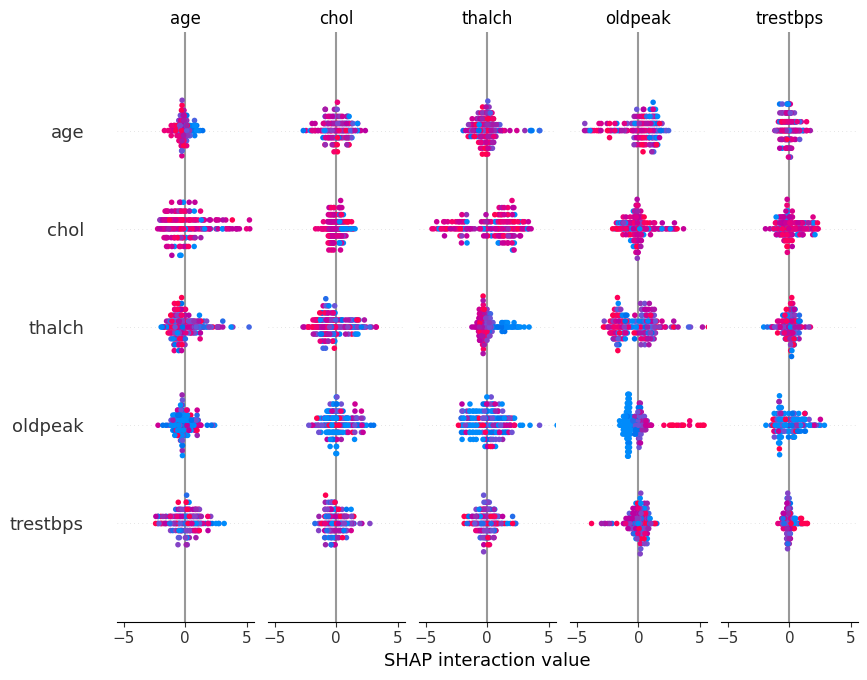

In [101]:
lgbm.fit(X_train, y_train)

explainer = shap.TreeExplainer(lgbm)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [102]:
explainer = shap.TreeExplainer(best_lgbm)

shap_values = explainer.shap_values(X_test)

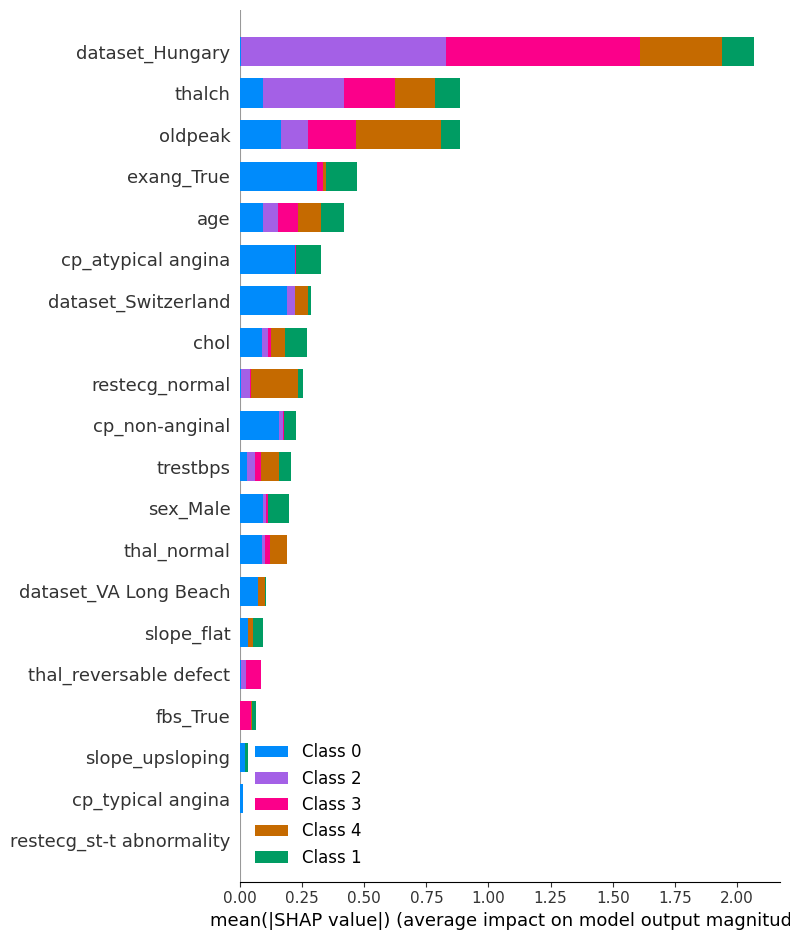

In [103]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

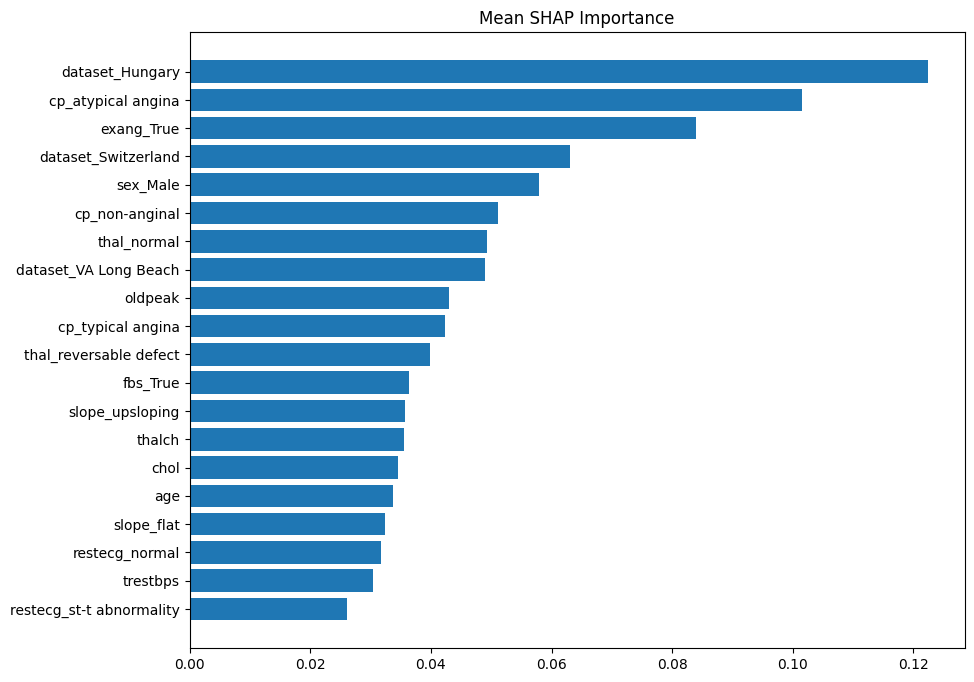

In [105]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Mean SHAP Importance")

plt.show()

# Stage_10(Importing)

In [112]:
import pickle

pickle.dump(xgb, open("heart_model.pkl", "wb"))

In [113]:
pickle.dump(scaler, open("scaler.pkl", "wb"))